<a href="https://colab.research.google.com/github/keshav123333/LLM_From_Scratch/blob/main/LLM_FROM_SCRATCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lecture 7 - tokens building regex**

In [ ]:
with open("the-verdict.txt","r",encoding="utf-8") as f:
  raw_text=f.read();
print(f"total no. of character: {len(raw_text)}")



total no. of character: 20479


In [ ]:
import re

😀 You can understand regex from this :https://chatgpt.com/share/68dc3869-3240-800a-aea9-46325a59929b

In [ ]:
text="hello, world+ is. the --best|"
processed=re.split(r'([,.*:;?_!"()\'\|+]|--|\s+)',raw_text)
result=[item.strip() for item in processed if item.strip()]

In [ ]:
len(result)

4690

Yaha pe no. ko map kiya ki vo ek array ke fo\\:rm m ho gaya vocab banani thi

toh bas jitne no. usko sorted

In [ ]:
vocab_rawdata=sorted(set(result))
vocab_rawdata.extend(["<|endoftext|>","<|unk|>"])


In [ ]:
vocab={token:idx for idx,token in enumerate(vocab_rawdata)}

In [ ]:
class SimpleTokenizerV1:
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={x:i for i,x in vocab.items()}

  def encode(self,text):
    preprocessed=re.split(r'([,.:?;_!"()\']|--|\||\s+)',text)
    preprocessed=[item.strip() for item in preprocessed if item.strip()]
    result=[self.str_to_int[token] if token in self.str_to_int else self.str_to_int["<|unk|>"] for token in preprocessed ]
    return result

  def decode(self,tokens):
     text=" ".join([self.int_to_str[token] for token in tokens])
     text=re.sub(r'\s+([,.?!()\'])',r'\1',text)   #here ima removing space from heloo ? to heloo?
     return text


In [ ]:
tokenizer=SimpleTokenizerV1(vocab)
text= " hello it ' s the last he painted, you know,"
ids=tokenizer.encode(text)
print(ids)
print(text)

[1131, 585, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5]
 hello it ' s the last he painted, you know,


In [ ]:
print(tokenizer.decode(ids))

<|unk|> it' s the last he painted, you know,


# **lecture 8 - Byte pair encoding**

In [ ]:
!pip3 install tiktoken

In [ ]:
import tiktoken

In [ ]:
import importlib
import tiktoken

print(importlib.metadata.version("tiktoken"))

0.12.0


In [ ]:
tokenizer=tiktoken.get_encoding("gpt2")

In [ ]:
text=("hello , do you like a tea <|endoftext|> in the sunlit")
enocde=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
print(enocde)

[31373, 837, 466, 345, 588, 257, 8887, 220, 50256, 287, 262, 4252, 18250]


In [ ]:
tokenizer.decode(enocde)

'hello , do you like a tea <|endoftext|> in the sunlit'

# lecture 9 - Creating input output target pair

In [ ]:
with open("the-verdict.txt",'r',encoding='utf-8') as f:
  raw_text=f.read()


FileNotFoundError: [Errno 2] No such file or directory: 'the-verdict.txt'

In [ ]:
enc_text=tokenizer.encode(raw_text,allowed_special={"<|endoftext|>"})
print(len(enc_text))

5145


In [ ]:
tokenizer.decode(enc_text[:5])

'I HAD always thought'

In [ ]:
inp=[]
tar=[]
context_size=4
for i in range(len(enc_text[:5])):
  if i<=context_size:
   inp.append(enc_text[:i])
   tar.append(enc_text[i])
   continue
  inp.append(enc_text[i-context_size:i])
  tar.append(enc_text[i])


In [ ]:
inp

[[], [40], [40, 367], [40, 367, 2885], [40, 367, 2885, 1464]]

In [ ]:
p=[]
for i in range(5):
    inp1 = inp[i]
    tar1 = tar[i]

    decoded_inp = tokenizer.decode(inp1)
    p.append(decoded_inp)
    decoded_tar = tokenizer.decode([tar1])
    print(f"Input: {decoded_inp}, Target: {decoded_tar}")




Input: , Target: I
Input: I, Target:  H
Input: I H, Target: AD
Input: I HAD, Target:  always
Input: I HAD always, Target:  thought


**implementing the dataset in inputoutput pair**


step 1 - devide the pair in input output par such
[[how are you]]   tar-> [[are you there]]
so when how is inp are is out when how are is inp you is output and it will go on and we will try to make such pair but in tensor form

In [ ]:
import torch
!pip install tiktoken
import tiktoken

In [ ]:
from torch.utils.data import Dataset,DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_le,stride):
    self.inp_ids=[]
    self.tar_ids=[]
    encoded=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})

    for i in range(0,len(encoded)-max_le,stride):
      inputchunks=encoded[i:i+max_le]
      targetchunks=encoded[i+1:i+max_le+1]
      self.inp_ids.append(torch.tensor(inputchunks))
      self.tar_ids.append(torch.tensor(targetchunks))

  def __len__(self):
    return len(self.inp_ids)

  def __getitem__(self,idx):
    return self.inp_ids[idx],self.tar_ids[idx]

In [ ]:
def create_dataset_v1(txt,batch_size=4,max_le=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding('gpt2')
  dataset=GPTDatasetV1(txt,tokenizer,max_le,stride)
  data_loader=DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)   #ye checl larega getitem and input output pair ko check karega and banayega and bas aise banata hai data
  return data_loader

dataset prepare in desired format

In [ ]:
with open("the-verdict.txt",'r',encoding='utf-8') as f:
  raw_text=f.read()

In [ ]:
dataset_v1=create_dataset_v1(raw_text,batch_size=8,max_le=4,stride=4,shuffle=False)
data_iter=iter(dataset_v1)
print(next(data_iter))

[tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]]), tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])]


# Lecture 10 - What are token embeding and how to do it using word2vec and other technique

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 14.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompat

In [ ]:
import gensim.downloader as api


In [ ]:
import torch

In [ ]:
model=api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
model['computer']   #this is vector embedding that represent computer  ye 300 dim ka vector hoga

array([ 1.07421875e-01, -2.01171875e-01,  1.23046875e-01,  2.11914062e-01,
       -9.13085938e-02,  2.16796875e-01, -1.31835938e-01,  8.30078125e-02,
        2.02148438e-01,  4.78515625e-02,  3.66210938e-02, -2.45361328e-02,
        2.39257812e-02, -1.60156250e-01, -2.61230469e-02,  9.71679688e-02,
       -6.34765625e-02,  1.84570312e-01,  1.70898438e-01, -1.63085938e-01,
       -1.09375000e-01,  1.49414062e-01, -4.65393066e-04,  9.61914062e-02,
        1.68945312e-01,  2.60925293e-03,  8.93554688e-02,  6.49414062e-02,
        3.56445312e-02, -6.93359375e-02, -1.46484375e-01, -1.21093750e-01,
       -2.27539062e-01,  2.45361328e-02, -1.24511719e-01, -3.18359375e-01,
       -2.20703125e-01,  1.30859375e-01,  3.66210938e-02, -3.63769531e-02,
       -1.13281250e-01,  1.95312500e-01,  9.76562500e-02,  1.26953125e-01,
        6.59179688e-02,  6.93359375e-02,  1.02539062e-02,  1.75781250e-01,
       -1.68945312e-01,  1.21307373e-03, -2.98828125e-01, -1.15234375e-01,
        5.66406250e-02, -

In [ ]:
print(model.most_similar(positive=['king','woman'],negative=['man'],topn=10))

[('queen', 0.7118193507194519), ('monarch', 0.6189674139022827), ('princess', 0.5902431011199951), ('crown_prince', 0.5499460697174072), ('prince', 0.5377321839332581), ('kings', 0.5236844420433044), ('Queen_Consort', 0.5235945582389832), ('queens', 0.5181134343147278), ('sultan', 0.5098593831062317), ('monarchy', 0.5087411999702454)]


In [ ]:
print(model.similarity('computer','laptop')) #so similarity score dega
print(model.similarity('king','queen'))

0.66404927
0.6510957


In [ ]:
model.most_similar('kite',topn=10) #10 siilar element dega

[('kites', 0.7965528964996338),
 ('kite_flying', 0.5787728428840637),
 ('stunt_kites', 0.5725536942481995),
 ('parasail', 0.566891074180603),
 ('paraglider', 0.5641922354698181),
 ('glider', 0.5606074929237366),
 ('hang_glider', 0.5494372844696045),
 ('flying_kite', 0.5435261726379395),
 ('coracle', 0.5358939170837402),
 ('microlight', 0.53233402967453)]

In [ ]:
import numpy as np
vectordiff=model['king']-+model['woman']
np.linalg.norm(vectordiff)

3.6735513

just a code for visulizing how token created here main ek voacb size 6 and vector embedding 3 ka banunga

In [ ]:
vocab_size=6
embedding_dim=3

embdedding_layer=torch.nn.Embedding(vocab_size,embedding_dim)

In [ ]:
embdedding_layer.weight

Parameter containing:
tensor([[-0.0527,  1.1393, -0.4188],
        [ 0.1120, -0.1740,  1.3408],
        [ 0.6230,  1.1555,  1.5456],
        [ 0.2585, -0.2115,  1.0100],
        [-0.2210,  0.1850,  1.9268],
        [-0.6117,  1.1201,  0.3000]], requires_grad=True)

In [ ]:
embdedding_layer(torch.tensor([1,2,5,3]))

tensor([[ 0.1120, -0.1740,  1.3408],
        [ 0.6230,  1.1555,  1.5456],
        [-0.6117,  1.1201,  0.3000],
        [ 0.2585, -0.2115,  1.0100]], grad_fn=<EmbeddingBackward0>)

# Lecture 11 - Positional encoding How it really work

In [ ]:
inputs,target=next(data_iter)

In [ ]:
inputs

tensor([[  314,  2138,  1807,   340],
        [  561,   423,   587, 10598],
        [  393, 28537,  2014,   198],
        [  198,     1,   464,  6001],
        [  286,   465, 13476,     1],
        [  438,  5562,   373,   644],
        [  262,  1466,  1444,   340],
        [   13,   314,   460,  3285]])

In [ ]:
embeding=torch.nn.Embedding(50257,256)

In [ ]:
inputs_in=embeding(inputs)

bascially maan le [[256 no. for 1 char vector rep],[256 no. for 1 char vector rep],[256 no. for 1 char vector rep],[256 no. for 1 char vector rep]] aise 4*256 positional bana toh bhaale 8 batch toh har batch ke liye alag ni nbanyega tu fix encoding vector bayega and like ek context size 4 ka and har m 256 vetcor rep toh unse plus hota jayega

([8, 4, 256])  so pehla batch aaya usse plus hua ye hi psotional then dura aaya toh usse plus hua aise final jo ayega vo bhi ([8, 4, 256]) ishi size ka hoga bas pure data ke liye ek positional encoding train jo postion ka dhyan rakhega aise ni ki 50000 vocab size toh har word ke liye uska apna psotional vector hoga ni balki sabke liye same hi hoga vo yaad karge sab ki psotion

and size hoga context size *vector embeding

In [ ]:
pos_embedding_layer=torch.nn.Embedding(4,256)

In [ ]:
pos_embeddings=pos_embedding_layer(torch.arange(4))
pos_embeddings.shape

torch.Size([4, 256])

In [ ]:
inputs.shape

torch.Size([8, 4])

In [ ]:
final_emb=inputs_in+pos_embeddings

In [ ]:
final_emb.shape

torch.Size([8, 4, 256])

# lecture 18 Multi-head attention

step 1 ->  input aaya
example ke liye batch,num_tokken,din=(1,3,6)  means har tokken -> tokken meatlab word so yaha pe word ho sakta i love you and har word ke liye 6 vector emb hai usko represent karne ke liye

num_tokens=3 and d_in=6 d_in means kitne vector

step 2-> decide the d_out Now question may arise what is d_out so   d_out is a contructor or we can kitna bada aap chate apka final context vector jaise maan yaha num of token hai 3 for "i love you" so context vector vo jo query ko key se then value se into karna pe aata uska size bhi (num_token,d_out) hota

d_out ko kitna bhi bada rakh sakte like 2 3 4 gpt 3 mein 96 tha

step 3-> Initialise the wt mat so wt mat =(d_in,d_out) and d_in vector emb, d_out-> is final eontext vector ko kitna bada chate tum

step 4-> compute input*wkey input*wquery input*wvalue

so input =(1,3,6) *wkey(6,6) =(1,3,6->d_out) ->like this we will do for other too


Step 5 ->  num_heads -> ye hai basically kitni matrix chaiye thumhe vo
           ab maan d_out tune liya hai 6
           num_heads =2 so num_head_dim=d_out/nums_head  6/2=3
           so ek ek matrix (num of tokken=3)*(3=ye num_head_dim)
           so if maan abhi input*wkey pe (1,3,6) na but isse (1,3,2,3) m badal jata so if example word "i love you"
[
  [  # batch 0
    [  # first 2x3 matrix
      [1, 2, 3] ye dono i ko reprensent krte hai ek matrix ka i ka query vector ye and second ka niche wala
      [4, 5, 6]
    ],
    [  # second 2x3 matrix
      [7, 8, 9], same goes for all ye dono love ka for both matrix
      [10, 11, 12]
    ],
    [  # third 2x3 matrix
      [13, 14, 15], ye you ko reprensent karte
      [16, 17, 18]
    ]
  ]
]









step 6. So ab humare pas sabse important step hai ab at last humare pas jo (1,3,2,3) ka batch hai usse (1,2,3,3) kar denge means

Maan input * 2 wkey matrix se kiya so pehle wale representation m (1,3,2,3) isme hum word ki emb ko group karte based on words ki ki i ki emb key  ek sath ek sath but ab hum matrix ke hisab se ki pehli matrix for i love you teeno ke liye ek sath then dusri mat for all token ek sath it help in computatiion



and ye cheez for key query and value teeno matrix ke liye kareenge aise hi (1,2,3,3) ki mat for each



```
Step 7-> now ab hum ek aur cheez karenge jo main hai
query*keyT so (1,2,3,3)*(1,2,3,3) sirf last ki (3,3)*(3,3) jogi pehle do value same ayegi so jab ye toh final mat we get is of (1,2,3,3)
```



Step 8 -> noew jo matrix usspe cusal attention mean digonal se upar walin matrix zero and then ek matrix (1,2,3,3) jiske dig se upar ka zero

now we will divide each col by sqrt(dout/num_head)=sqrt(6/2) thik 3 se
then softmax laga de ispe and hume final attention mat mil gayi eg

step 9 -> bas ab iss attention score ko multiply kar de value matrix se so final cotext vector humare pas ayega (1,2,3,3) iss size ka so yes aa gaya

step 10 hum vapis transpose (1,2,3,3) -> change to (1,3,2,3) as ab hum flatten so finally (1,3,6) mil jayega so i ke liye represent 6 context vector and aise love ke liye bhi you ke liye bhi

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean yaha tak caheh
        #tu emb for each word 300 le le attn score ka dim (1,num_head,num_tokken,num_token hi hota so ye work karta isliye)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

# Lecture 20 Layer Normalization

do it from notebook

In [ ]:
import torch

In [ ]:
import torch
import torch.nn as nn
torch.manual_seed(123)
batch_example=torch.randn(2,5)
layer=nn.Sequential(torch.nn.Linear(5,6),torch.nn.ReLU(),)#torch.nn.Linear(6,23))
out=layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print(mean)
print(var)

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [ ]:
out_mean=(out-mean)/torch.sqrt(var+1e-5)
print(out_mean)

tensor([[ 0.6157,  1.4123, -0.8717,  0.5871, -0.8717, -0.8717],
        [-0.0189,  0.1121, -1.0875,  1.5171,  0.5647, -1.0875]],
       grad_fn=<DivBackward0>)




```
now we will make layer norm for gpt 2
```



In [ ]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.shift=nn.Parameter(torch.zeros(emb_dim))


  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True,unbiased=False)# so if unbiased true toh var ke tiime n-1 se into but like n se kar le koi farak ni padta
    out=(x-mean)/torch.sqrt(var+self.eps)
    out=self.scale*out+self.shift
    return out

# lecture 21  feed forward gelu activation

In [ ]:
from torch import nn

In [ ]:
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":256,
    "emb_dim":768,
    "n_layers":12,
    "n_heads":12,
    "drop_rate":0.1,
    "qkv_bias":False
    }

In [ ]:
class GELU(nn.Module):
    def __init__(self):
      super().__init__()


    def forward(self,x):
      return 0.5*x*(1+torch.tanh(
          torch.sqrt(torch.tensor(2/torch.pi))*(x+0.044715*torch.pow(x,3))
      ))

feed forward

In [ ]:
class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
    )

  def forward(self,x):
    return self.layers(x)

In [ ]:
ffn=FeedForward(GPT_CONFIG_124M)
data=torch.randn((2,3,768))
print(data.shape)
out=ffn(data)
print(out.shape)

torch.Size([2, 3, 768])
torch.Size([2, 3, 768])


# Lecture 22 -: Skip connection

detailed advantages in copy

In [ ]:
import torch

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self,layer_sizes,use_shortcut):
    super().__init__()
    self.use_shortcut=use_shortcut
    self.layers=nn.ModuleList([
      # nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]),GELU())
      # nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]),GELU())
      # nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]),GELU())
      # ye kar sakta hai ya
       nn.Sequential(nn.Linear(layer_sizes[i],layer_sizes[i+1]),GELU())
      for i in range(len(layer_sizes)-1)
    ])

  def forward(self,x):
    for layer in self.layers:
        layer_out=layer(x)
        if self.use_shortcut and x.shape==layer_out.shape:
          x=x+layer_out
        else:
          x=layer_out
    return x



In [ ]:
def print_gradient(model,x):
  output=model(x)
  target=torch.tensor([[0.]])

  loss=nn.MSELoss()
  loss=loss(output,target)

  loss.backward()

  for name, param in model.named_parameters():
    if 'weight' in name :
      print(f"{name} gradient: {param.grad.abs().mean().item()}")

In [ ]:
layer_size=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.,-1.]])
torch.manual_seed(43)
model_withoutshortcut=ExampleDeepNeuralNetwork(layer_size,use_shortcut=False)
model_withshortcut=ExampleDeepNeuralNetwork(layer_size,use_shortcut=True)


In [ ]:
print_gradient(model_withoutshortcut,sample_input) #so layer 1 tak aate aate grad chpota ho gaya

layers.0.0.weight gradient: 0.00015519945009145886
layers.1.0.weight gradient: 0.0004362225881777704
layers.2.0.weight gradient: 0.000615256663877517
layers.3.0.weight gradient: 0.0033740652725100517
layers.4.0.weight gradient: 0.022268304601311684


In [ ]:
print_gradient(model_withshortcut,sample_input) # yaha utna chopta ni hua

layers.0.0.weight gradient: 0.005822501145303249
layers.1.0.weight gradient: 0.004644100554287434
layers.2.0.weight gradient: 0.005005298648029566
layers.3.0.weight gradient: 0.0132211335003376
layers.4.0.weight gradient: 0.059683237224817276


# lecture 23,24 - coding transformer block and gpt model

In [ ]:
import torch
from torch import nn

In [ ]:
class LayerNorm(nn.Module):
  def __init__(self,emb_dim):
    super().__init__()
    self.eps=1e-5
    self.scale=nn.Parameter(torch.ones(emb_dim))
    self.shift=nn.Parameter(torch.zeros(emb_dim))


  def forward(self,x):
    mean=x.mean(dim=-1,keepdim=True)
    var=x.var(dim=-1,keepdim=True)
    norm_x=(x-mean)/torch.sqrt(var+self.eps)
    return self.scale*norm_x+self.shift

class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self,x):
    return  0.5*x*(1 +torch.tanh(torch.sqrt(torch.tensor(2/torch.pi))*(x+0.0447+torch.pow(x,3))))

class FeedForward(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.layers=nn.Sequential(
        nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
        GELU(),
        nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
    )


  def forward(self,x):
   return self.layers(x)


In [ ]:
class TransformerBlock(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.att=MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"],
        num_heads=cfg["n_heads"]

    )
    self.ff=FeedForward(cfg)
    self.norm1=LayerNorm(cfg["emb_dim"])
    self.norm2=LayerNorm(cfg["emb_dim"])
    self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

  def forward(self,x):
    shortcut=x
    x=self.norm1(x)
    x=self.att(x)
    x=self.drop_shortcut(x)
    x=shortcut+x


    shortcut=x
    x=self.norm2(x)
    x=self.ff(x)
    x=self.drop_shortcut(x)
    x=shortcut+x
    return x


##gpt model

In [ ]:
class GPTMODEL(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks=nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)



  def forward(self,in_idx):
     batch_size,seq_len=in_idx.shape
     tok_embeds=self.tok_emb(in_idx)
     pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
     x=tok_embeds+pos_embeds
     x=self.drop_emb(x)
     x=self.trf_blocks(x)
     x=self.final_norm(x)
     logits=self.out_head(x)
     return logits

In [ ]:
#testing

model=GPTMODEL(GPT_CONFIG_124M)
batch = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, 4))
out=model(batch)

In [ ]:
out.shape

torch.Size([2, 4, 50257])

parameters in model

In [ ]:
total_params=sum(p.numel() for p in model.parameters())
print(f"{total_params:,}M parameters")


163,009,536M parameters


questionmay arise ki gpt 2 mein 124million parmeter the isme iten zayda aksie
so gpt 2 model ne jo param tok emb ke time liye the vo hi final out_head mein use kiye the for calculating final

In [ ]:
print("token emb layer shpe",model.tok_emb.weight.shape)
print("output layer shape",model.out_head.weight.shape)
#so isliye real model mein humne jis emb se tok emb uhe hi outlayer bi banayi thi unhi weight ko use karke


token emb layer shpe torch.Size([50257, 768])
output layer shape torch.Size([50257, 768])


In [ ]:
total_params=total_params-sum(p.numel() for p in model.out_head.parameters())
print(f"{total_params:,}M parameters") #so ab hume 124 parmas hi milnge

124,412,160M parameters


In [ ]:
model_size_bytes = total_params * 4  # float32 → 4 bytes
model_size_mb = model_size_bytes / (1024 ** 2)
print(f"Model size ≈ {model_size_mb:.2f} MB")

Model size ≈ 621.83 MB


#lecture 25 - predict next token

In [ ]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]  ##ye isliye maan le kisi case mein if maan le
    #input context size se bada contexr size 4 and input 10 word ka so last ke 4 word lega and next word predict and add karta rahega
    with torch.no_grad():
     logits=model(idx_cond)

    # Select the last token's logits (current position) and apply softmax
    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1) # softmax gives probabilities

    # Sample the next token from the probability distribution
    idx_next = torch.multinomial(probas, num_samples=1) # Sample one token based on probabilities

    # Append the sampled token to the sequence
    idx=torch.cat((idx,idx_next),dim=1)
  return idx

In [ ]:
def text_to_token_ids(text, tokenizer):
    return torch.tensor(tokenizer.encode(text)).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    # Ensure token_ids is on CPU before decoding
    if token_ids.is_cuda:
        token_ids = token_ids.cpu()
    return tokenizer.decode(token_ids.squeeze(0).tolist())

# lecture 26 - loss function and

isko copy se kar le

# Lecture 27 Evaluating LLM Performance on real dataset real training

In [ ]:
import os
import urllib.request
import torch
from torch import nn

In [ ]:
file_path="/content/the-verdict.txt"

with open(file_path,"r",encoding="utf-8") as file:
  text_data=file.read()

In [ ]:
text_data[:10]

'I HAD alwa'

In [ ]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

In [ ]:
total_characters=len(text_data)
total_tokens=len(tokenizer.encode(text_data))
print("tokens :",total_tokens)
print("characters :",total_characters)


tokens : 5145
characters : 20479


In [ ]:
from torch.utils.data import Dataset,DataLoader

class GPTDatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_le,stride):
    self.inp_ids=[]
    self.tar_ids=[]
    encoded=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})

    for i in range(0,len(encoded)-max_le,stride):
      inputchunks=encoded[i:i+max_le]
      targetchunks=encoded[i+1:i+max_le+1]
      self.inp_ids.append(torch.tensor(inputchunks))
      self.tar_ids.append(torch.tensor(targetchunks))

  def __len__(self):
    return len(self.inp_ids)

  def __getitem__(self,idx):
    return self.inp_ids[idx],self.tar_ids[idx]

def create_dataset_v1(txt,batch_size=4,max_le=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding('gpt2')
  dataset=GPTDatasetV1(txt,tokenizer,max_le,stride)
  data_loader=DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,drop_last=drop_last,num_workers=num_workers)   #ye checl larega getitem and input output pair ko check karega and banayega and bas aise banata hai data
  return data_loader

In [ ]:
#Train/ Val loss
train_ratio=0.90
split_idx=int(train_ratio*len(text_data))
train_data=text_data[:split_idx]
val_data=text_data[split_idx:]

torch.manual_seed(123)

train_loader=create_dataset_v1(
    train_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


val_loader=create_dataset_v1(
    val_data,
    batch_size=2,
    max_le=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
)


In [ ]:
#sanity check

if total_tokens*(train_ratio)<GPT_CONFIG_124M["context_length"]:
  print("train ke liye not enough tokens")

if total_tokens*(1-train_ratio)<GPT_CONFIG_124M["context_length"]:
  print("not enough val data")

In [ ]:
print("train loader:")
for batch in train_loader:
  print(batch[0].shape)
  print(batch[1].shape)

print("\n Validation loader")

for batch in val_loader:
  print(batch[0].shape)
  print(batch[1].shape)


train loader:
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])
torch.Size([2, 256])

 Validation loader
torch.Size([2, 256])
torch.Size([2, 256])


In [ ]:
class GPTMODEL(nn.Module):
  def __init__(self,cfg):
    super().__init__()
    self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
    self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
    self.drop_emb=nn.Dropout(cfg["drop_rate"])
    self.trf_blocks=nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm=LayerNorm(cfg["emb_dim"])
    self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)



  def forward(self,in_idx):
     batch_size,seq_len=in_idx.shape
     tok_embeds=self.tok_emb(in_idx)
     pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
     x=tok_embeds+pos_embeds
     x=self.drop_emb(x)
     x=self.trf_blocks(x)
     x=self.final_norm(x)
     logits=self.out_head(x)
     return logits

In [ ]:
model=GPTMODEL(GPT_CONFIG_124M)
model.eval()

GPTMODEL(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
def calc_loss_batch(input_batch,target_batch,model,device):
  input_batch,target_batch=input_batch.to(device),target_batch.to(device)
  logits=model(input_batch)
  # loss=nn.functional.cross_entropy(logits.view(-1,logits.shape[-1]),target_batch.view(-1))
#  both give same result farak karne ka hai chagpt
#  logits: flatten(0,1) → [B*T, V]
# targets: flatten()   → [B*T]
# flatten(0,1) = dim 0 aur dim 1 ko merge kar do.


  loss=nn.functional.cross_entropy(logits.flatten(0,1),target_batch.flatten())
  return loss

In [ ]:
def calc_loss_loader(data_loader,model,device,num_batches=None):
  total_loss=0
  if len(data_loader)==0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)

  else:
    num_batches=min(num_batches,len(data_loader))

  for i ,(input_batch,target_batch) in enumerate(data_loader):
    if i< num_batches:
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      total_loss+=loss.item()
    else :
      break
  return total_loss/num_batches


In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


model.to(device)
torch.manual_seed(123)

with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device)
  val_loss=calc_loss_loader(val_loader,model,device)

print("train loss : ",train_loss)
print("validation loss : ",val_loss)



train loss :  11.011739518907335
validation loss :  10.955327987670898


# pretrain model backward pass

In [ ]:
def train_model_simple(model,train_loader,val_loader,optimizer,device,num_epochs,
                       eval_freq,eval_iter,start_context,tokenizer):
  train_losses,val_losses,track_tokens_seen=[],[],[]
  tokens_seen,global_step=0,-1;


  #main loop
  for epoch in range(num_epochs):
    model.train()
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()  # reset loss gradient from previuos batch
      loss =calc_loss_batch(input_batch,target_batch,model,device)
      loss.backward() #grad cal for every parameter
      optimizer.step() #update weights w=w-lr*grad
      tokens_seen+=input_batch.numel()
      global_step+=1

      #optional eval step
      if global_step%eval_freq==0:
        train_loss,val_loss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"Epoch{epoch+1} (step : {global_step:06d}):"
        f" train loss : {train_loss:.4f} val loss : {val_loss:.4f}")
    generate_and_print_sample(model,tokenizer,device,start_context)
  return train_losses,val_losses,track_tokens_seen

In [ ]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    val_loss=calc_loss_loader(val_loader,model,device,num_batches=eval_iter)
  model.train()
  return train_loss,val_loss

In [ ]:
def generate_and_print_sample(model,tokenizer,device,start_context):
  model.eval()
  # Fixed: Changed 'weights' to 'weight'
  context_size=model.pos_emb.weight.shape[0]
  encoded=text_to_token_ids(start_context,tokenizer).to(device)
  with torch.no_grad():
    token_ids=generate_text_simple(
        model=model,idx=encoded,
        max_new_tokens=50,context_size=context_size
    )
  decoded_text=token_ids_to_text(token_ids,tokenizer)
  print(decoded_text.replace("\n"," "))
  model.train()

In [ ]:
import time
start_time=time.time()

torch.manual_seed(123)
model=GPTMODEL(GPT_CONFIG_124M)
model.to(device)
optimizer=torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.1)
num_epocs=10
train_losses,val_losses,track_tokens_seen=train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epocs,
    eval_freq=5,
    eval_iter=10,
    start_context="Tevery effort moves you",
    tokenizer=tokenizer
)

end_time=time.time()
elapsed_time=(end_time-start_time)/60
print(f"train complete in {elapsed_time} minutes")

Epoch1 (step : 000000): train loss : 9.5344 val loss : 9.6714
Epoch1 (step : 000005): train loss : 6.9112 val loss : 7.1890
Tevery effort moves you timeorb my why as to that't said her- more havingawaruis "-- his an he _ a he gluc had foreffects asweet that was " that G my--Yes saw: a an" aboutI in I- he.ura
Epoch2 (step : 000010): train loss : 6.2355 val loss : 6.7139
Epoch2 (step : 000015): train loss : 6.0306 val loss : 6.7204
Tevery effort moves you theivec half of did he, it. laugh she G-- rich of the could are called sketch. glanced towardis neutral paint ofs-- She, under left_ work the wide had foundations outest of dashed amusing G grew ofhis brav
Epoch3 (step : 000020): train loss : 5.8727 val loss : 6.6667
Epoch3 (step : 000025): train loss : 5.7246 val loss : 6.7384
Tevery effort moves you . managed his--The aud--    You prince have up and own Mrs followed of about come:He he it unexpected    a uncertain called under a cured looking I laid his pard."   "   "
Epoch4 (step : 0

In [ ]:
## if no. of trainable param

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_params)


#3 trainable and non trainable params dono
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total)
print("Trainable parameters:", trainable)




#if architecture ise chaiye
# for name, p in model.named_parameters():
#     if p.requires_grad:
#         print(name, p.numel())


Trainable parameters: 162419712
Total parameters: 162419712
Trainable parameters: 162419712


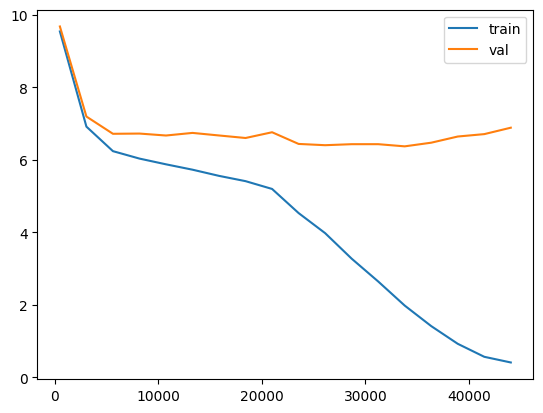

In [ ]:
import matplotlib.pyplot as plt
plt.plot(track_tokens_seen,train_losses,label="train")
plt.plot(track_tokens_seen,val_losses,label="val")
plt.legend()

#Implemeting topk And temperature scaing

In [ ]:
eos_id=50256
def generate(model,idx,max_new_tokens,context_size,top_k=None,temperature=0):
  for _ in range(max_new_tokens):
    idx_cond=idx[:,-context_size:]
    with torch.no_grad():
      logits=model(idx_cond)
    logits=logits[:,-1,:]

    if top_k is not None:
      top_logits,_=torch.topk(logits,k=top_k)
      min_val=top_logits[:,-1]
      logits=torch.where(logits<min_val,torch.tensor(float("-inf")).to(logits.device),logits)
    if temperature>0.0:
      logits=logits/temperature

      probs=torch.softmax(logits,dim=-1)
      idx_next=torch.multinomial(probs,num_samples=1)
    else:
      idx_next=torch.argmax(logits,dim=-1,keepdim=True)

    if idx_next==eos_id:
      break

    idx=torch.cat((idx,idx_next),dim=1)

  return idx


In [ ]:
tokenizer=tiktoken.get_encoding("gpt2")
token_ids=generate(
    model=model,
    idx=text_to_token_ids("every effort moves you",tokenizer).to(device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temperature=1.4
)
print(token_ids_to_text(token_ids,tokenizer))

#model weight save

In [ ]:
#only model ko save toh

model=GPTModel(GPT_CONFIG_124M)
torch.save(model.state_dict(),"model.pth")


#load
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()

In [ ]:
# but hume optimizer ko bhi save karna hoga jo use hua so if

#save the weight
optimizer=torch.optim.AdamW(model.parameters(),lr,weight_decay=0.1)
torch.save({
    "model_state_dict":model.state_dict(),
    "optimizer_state_dict":optimizer.state_dict()
},
           "model_and_optimizer.pth")

In [ ]:
checkpoint=torch.load("model_and_optimizer.pth")
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer=torch.optim.AdamW(model.parameters(),lr,weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.eval() # model.train() bhi kar sakta if train karna hai toh

# pretrained gpt model weight and biases

lecture 32 dekh imp hai vo last m kya hai usse samjhne ke lye

In [ ]:
import tensorflow as tf
import numpy as np
import tqdm
import torch

print(tf.__version__)
print(tqdm.__version__)

2.19.0
4.67.1


In [ ]:
import os
import requests  # Make sure requests is installed
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path)

    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:
settings,params=download_and_load_gpt2(model_size="124M",models_dir="gpt2")  #isme hum like gpt2 model and 124M wala gpt model ko use karna chate hai ye pass kar dete hai


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 69.2kiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 6.64MiB/s]
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verifica

In [ ]:
print(settings)
print(params.keys()) # params weigths hai

{'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [ ]:
print(params["wte"].shape) #wte toekn emb hai like humari vocab size hai 50000 ke lagbhag and har word ko 768 dim se represent

(50257, 768)


In [ ]:
model_configs={
    "gpt2-small (124M)": {"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium (355M)": {"emb_dim":1024,"n_layers":24,"n_heads":16},
    "gpt2-large (774M)": {"emb_dim":1265,"n_layers":36,"n_heads":20},
    "gpt2-xl (1558M)": {"emb_dim":1600,"n_layers":48,"n_heads":25},
}



model_name="gpt2-small (124M)"
NEW_CONFIG=GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])


In [ ]:
NEW_CONFIG.update({"context_length":1024,"qkv_bias":True}) #purane mein humne train datashortage ki wajah se kuch config apne hisab se likh di thi vo sahi kari hai
gpt=GPTMODEL(NEW_CONFIG)
gpt.eval();

In [ ]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [ ]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In [ ]:
load_weights_into_gpt(gpt, params)
gpt.to("cpu");

In [ ]:
device="cpu"

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you an understanding of the new aeulve!

What makes

Fur on, what do you get one


#**Fine tunning with classification**

In [ ]:
import urllib.request
import ssl
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Create an unverified SSL context
    ssl_context = ssl._create_unverified_context()

    # Downloading the file
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)


File downloaded and saved as sms_spam_collection/SMSSpamCollection.tsv


In [ ]:
import os
import zipfile
import requests
import pandas as pd

def load_sms_spam_dataset(
    url="https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip",
    extract_dir="sms_data"
):
    # 1. Create directory if not exists
    os.makedirs(extract_dir, exist_ok=True)

    zip_path = os.path.join(extract_dir, "sms_spam.zip")

    # 2. Download zip
    response = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(response.content)

    # 3. Extract zip
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    # 4. Load file into DataFrame
    data_path = os.path.join(extract_dir, "SMSSpamCollection")
    df = pd.read_csv(
        data_path,
        sep="\t",
        header=None,
        names=["label", "message"]
    )

    return df


In [ ]:
df=load_sms_spam_dataset()

In [ ]:
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
def balanced_data(df):
  num_spam=df["label"].value_counts()["spam"].item()
  ham_subset=df[df["label"]=="ham"].sample(num_spam,random_state=123)
  balanced=pd.concat([ham_subset,df[df["label"]=="spam"]])
  balanced=balanced.sample(frac=1,random_state=123)
  return balanced


In [ ]:
balanced_df=balanced_data(df)

In [ ]:
balanced_df

,label,message
2087,ham,Dude how do you like the buff wind.
4694,ham,Tessy..pls do me a favor. Pls convey my birthd...
881,spam,Reminder: You have not downloaded the content ...
1172,spam,Got what it takes 2 take part in the WRC Rally...
2170,spam,"Shop till u Drop, IS IT YOU, either 10K, 5K, £..."
...,...,...
2109,spam,FREE2DAY sexy St George's Day pic of Jordan!Tx...
2730,spam,Urgent! Please call 09066612661 from your land...
4410,spam,For your chance to WIN a FREE Bluetooth Headse...
4903,spam,* FREE* POLYPHONIC RINGTONE Text SUPER to 8713...


In [ ]:
balanced_df["label"]=balanced_df["label"].map({"spam":1,"ham":0})

In [ ]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder


In [ ]:
print(len(train_df))
print(len(validation_df))
print(len(test_df))

1045
149
300


In [ ]:
train_df.to_csv("train.csv",index=False)
validation_df.to_csv("validation.csv",index=False)
test_df.to_csv("test.csv",index=False)
#

#lecture 34 dataloaders and load data


In [ ]:
#how we will load the dataset in this
# so dataloaders mein maan abhi hum spam not spam so isme message varying length ka ho sakte hai so
#isko handle ke liye we will do pad the text like jo sabse bada msg in our data hum baki sabko bhi same len ka karenge how

# hum endooftext kar denge like if ek text max size se kam so equal karne ke liye endoftext add kar denge uss chote text mein


#input text-> tokenize -> ensure that all sentence same size are same len

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
class SpamDataset(Dataset):
  def __init__(self,csv_file,tokenizer,max_length=None,pad_token_id=50256):
    self.data=pd.read_csv(csv_file)
#data ko pehle pad
    self.encoded_text=[
        tokenizer.encode(text) for text in self.data["message"]
    ]

    if max_length is None:
      self.max_length=self._longest_encoded_length()
    else:
      self.max_length=max_length

    #padding the seq

    self.encoded_text=[
        encodetext+[pad_token_id]*(self.max_length-len(encodetext))
        for encodetext in self.encoded_text
    ]


  def __getitem__(self, index) :
    encoded=self.encoded_text[index]
    label=self.data.iloc[index]["label"]
    return (torch.tensor(encoded),torch.tensor(label))

  def __len__(self):
    return len(self.data)

  def _longest_encoded_length(self):
    max_len=0;
    for encoded_text in self.encoded_text:
      max_len=max(max_len,len(encoded_text))
    return max_len


In [ ]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

In [ ]:
train_dataset=SpamDataset("train.csv",max_length=None,tokenizer=tokenizer)
print(train_dataset.max_length)

120


In [ ]:
val_dataset=SpamDataset("validation.csv",max_length=train_dataset.max_length,tokenizer=tokenizer)
test_dataset=SpamDataset("test.csv",max_length=train_dataset.max_length,tokenizer=tokenizer)

In [ ]:
from torch.utils.data import DataLoader

num_workers=0
batch_size=8

torch.manual_seed(123)
train_loader=DataLoader(train_dataset,batch_size=batch_size,num_workers=num_workers,drop_last=True)
val_loader=DataLoader(val_dataset,batch_size=batch_size, num_workers=num_workers,drop_last=False)
test_loader=DataLoader(val_dataset,batch_size=batch_size, num_workers=num_workers,drop_last=False)


In [ ]:
for input_batch,target_batch in train_loader:
  pass

print(input_batch.shape)
print(target_batch.shape)



torch.Size([8, 120])
torch.Size([8])


#leture 35 -: last layer model update

ab meri baat sun like ab hume last layer jo har word ke correspond tu notes dekh  

In [ ]:
print(gpt)

GPTMODEL(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [ ]:
#  (out_head): Linear(in_features=768, out_features=50257, bias=False)
# isme outfreature 2only

In [ ]:
#pehle sare param ka train false
for param in gpt.parameters():
  param.requires_grad=False

In [ ]:
torch.manual_seed(123)
num_classes=2
gpt.out_head=torch.nn.Linear(in_features=NEW_CONFIG["emb_dim"],out_features=num_classes)
#ab naya bna toh ye automatically trainable ho gaya

In [ ]:
for param in gpt.trf_blocks[-1].parameters():
  param.requires_grad=True

for param in gpt.final_norm.parameters():
  param.requires_grad=True

In [ ]:
#example before finatuning rough run
input=tokenizer.encode("Do you have time")
print(torch.tensor(input)) #unsqueze ne like batch me convertpehle ye sirf one dim mein ab 2 dim mein
inputs=torch.tensor(input).unsqueeze(0)
print(inputs)


tensor([[5211,  345,  423,  640]])
tensor([[5211,  345,  423,  640]])


In [ ]:
with torch.no_grad():
  outputs=gpt(inputs)

print(outputs)

tensor([[[-0.6080,  0.4975],
         [-2.1378,  4.6216],
         [-1.8640,  4.4252],
         [-3.1568,  4.4511]]])


#lecture 36 finding loss ,accuracy, fintune model

In [ ]:
# so like model ek array hum last wala
# with torch.no_grad():
#   outputs=gpt(inputs)

# print(outputs)
# tensor([[[-0.6080,  0.4975],
#          [-2.1378,  4.6216],
#          [-1.8640,  4.4252],
#          [-3.1568,  4.4511]]])
  # [-3.1568,  4.4511] ye utha lege and like isme hum pehle softmax then argmax se model
  # kya kaha raha 0 1 kya and then usse los and accuracy find karenge

In [ ]:
def calc_accuracy_loader(data_loader,model,device,num_batches=None):
  model.eval()
  correct_predictions,num_examples=0,0

  if num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(num_batches,len(data_loader))

  for i,(input,target) in enumerate(data_loader):
    if i<=num_batches:
      input,target=input.to(device),target.to(device)

      with torch.no_grad():
        logits=model(input)[:,-1,:]

      predicted_labels=torch.argmax(logit,dim=-1)
      num_examples+=predicted_labels.shape[0]
      correct_prediction+=(predicted_labels==target_batch).sum().item()

    else:
      break
  return correct_predictions/num_examples

In [ ]:
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device)
torch.manual_seed(123)
train_accuracy=calc_accuracy_loader(train_loader,gpt,device)
val_accuracy=calc_accuracy_loader(val_loader,gpt,device)
test_accuracy=calc_accuracy_loader(test_loader,gpt,device)
print(f"Train Accuracy: {train_accuracy*100:.2f}%")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")



loss calculate

In [ ]:
def calc_loss_batch(input_batch,target_batch,mode,device):
  input_batch,target_batch=input_batch.to(device),target_batch.to(device)
  logits=model(input_batch)[:,-1,:]
  loss=torch.nn.fucntional.cross_entropy(logits,target_batch)
  return loss

In [ ]:
def calc_loss_loader(data_loader,modedevice,num_batches):
  total_loss=0
  if len(data_loader)==0:
    return float("nan")
  elif num_batches is None:
    num_batches=len(data_loader)
  else:
    num_batches=min(num_batches,len(data_loader))

  for i,(input_batch,target_batch) in enumerate(data_loader):
    if i <num_batches:
      loss=calc_loss_batch(input_batch,target_batch,model,device)
    else:
      break
  return total_loss/num_batches

In [ ]:
with torch.no_grad():
  train_loss=calc_loss_loader(train_loader,model,device,num_batches=5)
  val_loss=calc_loss_loader(val_loader,model,device,num_batches=5)
  test_loss=calc_loss_loader(test_loader,model,device,num_batches=5)

print(train_loss)

loss and backward pass

In [ ]:
def train_classifier_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter):
  train_losses,val_losses,train_accs,val_accs=[],[],[],[]
  examples_seen,global_step=0,-1


  for epoch in range(num_epochs):
    model.train() #train mein  set
    for input_batch,target_batch in train_loader:
      optimizer.zero_grad()  #reset grad weight
      loss=calc_loss_batch(input_batch,target_batch,model,device)
      optimizer.step()
      example_seen+=input_batch.shape[0] #isme maan maine 130 kar rakha batch yaha toh 5 liye hai toh har 50 batch ke baad tri loss print maan
      global_step+=1


      if global_step %eval_freq==0
      train_loss,val_loss=evaulate_model(model,train_loader,val_loader,device,eval_iter)
      train_losses.append(train_loss)
      val_losses.append(val_loss)
      print(f"Ep {epoch+1} (step {global_step:06d} : train loss {train_loss:.4f} val loss {val_loss:.4f}")

      train_accuracy=calc_accuracy_loader(train_loader,model,device,num_batches=eval_iter)
      val_accuracy=calc_accuracy_loader(val_loader,model,device,num_batches=eval_iter)
      print(f"Trianing Accuracy: {train_accuracy*100:.2f}%")
      print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
      train_accs.append(train_accuracy)
      val_accs.append(val_accuracy)
  return train_losses,val_losses,train_accs,val_acc,example_seen


In [ ]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss=calc_loss_batch(train_loader,model,device,num_batches)
    val_loss
  model.train()
  return train_loss,val_loss

In [ ]:
import time
start_time=time_time()
torch.manual_seed(123)
optimizer=torch.optim.AdamW(gpt.parameters(),lr=3e-5)
num_epochs=5
train_losses,val_losses,train_accs,val_accs_example_seen=train_classifier_simple(gpt,train_loader,val_loader,optimizer,device,num_epochs=num_epochs,eval_freq=50,eval_iter=5)
end_time=time.time()
execution_time_minutes=(end_time-start_time)/60
print(f"Execution time: {execution_time_minutes:.2f} minutes")


In [ ]:
train_accuracy=calc_accuracy_loader(train_loader,gpt,device)
val_accuracy=calc_accuracy_loader(val_loader,gpt,device)
test_accuracy=calc_accuracy_loader(test_loader,gpt,device)
print(f"Train Accuracy: {train_accuracy}")
print(f"Validation Accuracy: {val_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

check if a text is spam or not

In [ ]:
def classify_review(text,model,tokenizer,device,max_length=None,pad_token_id=50256):

  model.eval()

  input_ids=tokenizer.encode(text)
  supported_context_length=model.pos_emb.weight.shape[0]

  input_ids=input_ids[:min(max_length,supported_context_length)]
  input_ids+=[pad_token_id]*(max_length-len(input_ids))
  input_tensor=torch.tensor(input_ids,device=device)
  input_tensor=input_tensor.unsqueeze(0)

  with torch.no_grad():
    logits=model(input_tensor)[:,-1,:]

  predicted_label=torch.argmax(logits,dim=-1)

  return "spam" if predicted_label ==1 else "not spam"

In [ ]:
text_1=(
    "you are a winner you have been specially"
    "selcted to receive $1000 cash or a $2000 award."
)

print(classify_review(text_1,gpt,tokenizer,device,max_length=train_dataset.max_length))

In [ ]:
# you can save the mode
torch.save(gpt.state_dict(),"review_classifier.pth")
model_state_dict=torch.load("review_classifier.pth")
gpt.load_state_dict(model_state_dict)

#Lecture 37 Intruction finetunning

In [ ]:
import json
import os
import urllib
import ssl

def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))


Number of entries: 1100


copy se padh ek dusra tarh ka vo bhi diya hai for same work

In [ ]:
data[712]   # iss fomat mein hota hai data answer iske sath hi bhej dete hai apan as uski main vajah hai ki like gpt model next word predict kart hai so vo jaan
# jaye ki instruction hote hai toh kya answer hone chaiye like instruction jo hai uske liye kya anwer aane chaiye

{'instruction': 'What is the capital of Spain?',
 'input': '',
 'output': 'The capital of Spain is Madrid.'}

In [ ]:
def format_input(entry):
  instruction_text= (
      f"Below is an instruction that describe a task. "
      f"Write a response that appropriately completes the request."
      f"\n\n### Instruction:\n{entry['instruction']}"

  )
  input_text=f"\n\n### Input: \n{entry['input']} " if entry["input"] else ""


  return instruction_text+input_text

#

In [ ]:
model_input=format_input(data[50])
desired_reponse=f"\n\n### Response:\n{data[50]['output']}"

print(model_input+desired_reponse) #ye jata hai model ke anadar

Below is an instruction that describe a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input: 
Ocassion 

### Response:
The correct spelling is 'Occasion.'


In [ ]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


#lecture 38 data prepare and loss cal

##see lecture 38 to know kaise out inp pair  

1. Isme first like instr input and res aise input output pair bana lete hai upar jo kiya

2. Then ab hum like sare token ki size diff toh max len lete token ki and then jo max len ka hai tokken utni padding sabme add 50256 token added

3. Create inp and out pair isme bhi next word pred hi jo upar tokenize kiya usse right shift and then main cheez 50256 ko -100 se replace
4. then loss cal

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
class InstructionDataset(Dataset):
  def __init__(self,data,tokenizer):
    self.data=data
    self.encoded_texts=[]
    for entry in data:
      instruction_plus_input=format_input(entry)
      response_text=f"\n\n Response : \n {entry['output']}"
      full_text=instruction_plus_input+response_text
      self.encoded_text.append(
          tokenizer.encode(full_text)
      )

  def __getitem__(self,index):
    return self.encoded_texts[index]
  def __len__(self):
    return len(self.data)

In [ ]:
def custom_collate_draft_1(batch,pad_token_id=50256,device="cpu"):
  batch_max_length=max(len(item)+1 for item in batch)
  input_lst=[]
  for item in batch:
    new_item=item.copy()
    new_item+=[pad_token_id] #ek extra padtoken add kar diya jisse max ke liye bhi ek padding ban sake
    padded=(
        new_item+[pad_token_id]*(batch_max_length-len(new_item))
    )

    inputs=torch.tensor(padded[:-1])
    input_lst.append(inputs)

  input_tensor=torch.stack(input_lst).to(device)
  return input_tensor

In [ ]:
input1=[0,1,2,3,4]
input2=[5,6]
input3=[7,8,9]

batch=(
    input1,
    input2,
    input3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [ ]:
def custom_collate_draft_2(batch,pad_token_id=50256,device="cpu"):
  batch_max_length=max(len(item)+1 for item in batch)
  input_lst,target_lst=[],[]
  for item in batch:
    new_item=item.copy()
    new_item+=[pad_token_id] #ek extra padtoken add kar diya jisse max ke liye bhi ek padding ban sake
    padded=(
        new_item+[pad_token_id]*(batch_max_length-len(new_item))
    )

    inputs=torch.tensor(padded[:-1])
    targets=torch.tensor(padded[1:])
    input_lst.append(inputs)
    target_lst.append(targets)

  input_tensor=torch.stack(input_lst).to(device)
  targets_tensor=torch.stack(target_lst).to(device)
  return input_tensor,targets_tensor

In [ ]:
input1=[0,1,2,3,4]
input2=[5,6]
input3=[7,8,9]

batch=(
    input1,
    input2,
    input3
)
inputs,targets=custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()

        if indices.numel() > 1:

            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor(4)
tensor([1, 2, 3, 4])
tensor([50256, 50256, 50256])
tensor([2, 3, 4])
tensor([50256, 50256])
tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [ ]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1]) #ye label hai ye pata karta like ki index ke hisab se kaun sa index answer hoga


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [ ]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, -100])
#abhi bhi loss same as 3rd wale mein -100 so vo iss wale label ko ignore kar dega as answer ni lega sirf upar ke do kis hsab se loss
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(1.1269)


In [ ]:
import torch

In [ ]:
#sun jaise masking and no maskig then input llm can benfits the model or not ye ek open research hai
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#dataloader data load

In [ ]:
from functools import partial
customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)
#dekh lena kya kaam hai iska chota sa hi hai kaam cotom collate mein device and allowed max len ko change karne ke liye

In [ ]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)
    #jab ye print toh varying like input and output len ayegi as sare data diff len ke vo toh jab
#eg : to Train loader:
# torch.Size([8, 61]) torch.Size([8, 61])
# torch.Size([8, 76]) torch.Size([8, 76])
# torch.Size([8, 73]) torch.Size([8, 73])
# aisa kuch hoga why AB MERI BAAT SUN AISE ISLIYE AS DATA LOADER HAR BATCH MEIN JO MAX USKE EQUAL KAR DETA LENTGH KO
# SO HAR BATCH OF 8 KE DIFF MAX AND DIFF MAX HONGE

#Pretrain Model with 355 Million model

lecture 40

In [ ]:
import tensorflow as tf
import numpy as np
import tqdm
import torch

print(tf.__version__)
print(tqdm.__version__)

In [ ]:
import os
import requests  # Make sure requests is installed
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm

def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path)

    ## We have reached here until now ---> we have downloaded the files on our local machine.

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json")))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params

def download_file(url, destination):
    try:
        # Send a GET request to download the file, disabling SSL verification
        response = requests.get(url, stream=True, verify=False)

        # Get the total file size from headers, defaulting to 0 if not present
        file_size = int(response.headers.get("content-length", 0))

        # Check if file exists and has the same size
        if os.path.exists(destination):
            file_size_local = os.path.getsize(destination)
            if file_size == file_size_local:
                print(f"File already exists and is up-to-date: {destination}")
                return

        # Define the block size for reading the file
        block_size = 1024  # 1 Kilobyte

        # Initialize the progress bar with total file size
        progress_bar_description = url.split("/")[-1]  # Extract filename from URL
        with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
            # Open the destination file in binary write mode
            with open(destination, "wb") as file:
                # Iterate over the file data in chunks
                for chunk in response.iter_content(block_size):
                    progress_bar.update(len(chunk))  # Update progress bar
                    file.write(chunk)  # Write the chunk to the file

    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
        print(f"Please check the URL: {url}")

def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [ ]:
model_configs={
    "gpt2-small (124M)": {"emb_dim":768,"n_layers":12,"n_heads":12},
    "gpt2-medium (355M)": {"emb_dim":1024,"n_layers":24,"n_heads":16},
    "gpt2-large (774M)": {"emb_dim":1265,"n_layers":36,"n_heads":20},
    "gpt2-xl (1558M)": {"emb_dim":1600,"n_layers":48,"n_heads":25},
}
BASE_CONFIG={
    "vocab_size":50257,
    "context_length":1024,
    "drop_rate":0.0,
    "qkv_bias":True
}


model_name="gpt2-medium (355M)"
NEW_CONFIG=BASE_CONFIG.copy()
NEW_CONFIG.update(model_configs[model_name])
model_size=model_name.split(" ")[-1].lstrip("(").rstrip(")")
settings, params=download_and_load_gpt2(model_size, model_dir="gpt2")
model=GPTModel(NEW_CONFIG)
load_weights_into_gpt(model,params)
model.eval()



In [ ]:
torch.manual_seed(123)
input_text=formate_input(val_data[50])

In [ ]:
token_ids=generate(
    model=model,
    idx=text_to_token_ids(input_text,tokenizer),

    max_new_tokens=100,
    context_size=NEW_CONFIG["context_length"],
    eos_id=50256
)

generated_text=token_ids_to_text(token_ids,tokenizer)


In [ ]:
response_text=generated_text[len(input_text):].strip()
print(response_text)

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


In [ ]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 1

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

upar wale bloack ko chalaiyo mat bahut time leta hai sala

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis f or tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

#Evaluating Model Performance

lecture 42

In [ ]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

In [ ]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

In [ ]:
print(test_data[0])
# {'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}
# iss format mein test data ke output ko store ek nayi file mein

In [ ]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

In [ ]:
#watch video most important lecture 42